# 04 — Lag structure

This notebook determines how many weeks of upstream price history are relevant for each link in the supply chain. It compares the crude -> retail, crude -> wholesale, and wholesale -> retail relationships using cross-correlation, then uses the resulting lag structure to choose the lag length K for the asymmetry model.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_repo_root(start: Path) -> Path:
    """Walk upward from `start` until a directory containing pyproject.toml is found."""
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("no pyproject.toml found in any parent directory")


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.lag_structure import cross_correlation, up_down_response
from scripts.verify_alignment import PROCESSED_DIR, RETAIL_SERIES_ID, UPSTREAM_SERIES_ID, load_series

DAILY_CRUDE_SERIES_ID = "DCOILWTICO"
WHOLESALE_SERIES_ID = "WGASUSGULF"  # role=core in the manifest — the Gulf Coast series used as "the" wholesale leg throughout

MAX_LAG = 12  # extends past the SPEC's suggested K range so decay into noise is actually visible

COLOR_CRUDE_RETAIL_WEEKLY = "#2a78d6"
COLOR_CRUDE_RETAIL_DAILY_PIT = "#1baf7a"
COLOR_CRUDE_WHOLESALE = "#4a3aa7"
COLOR_WHOLESALE_RETAIL = "#eda100"
COLOR_UP = "#eb6834"
COLOR_DOWN = "#2a78d6"

retail_full = load_series(PROCESSED_DIR / "retail.csv", RETAIL_SERIES_ID, "weekly-mon")
weekly_crude = load_series(PROCESSED_DIR / "crude.csv", UPSTREAM_SERIES_ID, "weekly-fri")
daily_crude = load_series(PROCESSED_DIR / "crude.csv", DAILY_CRUDE_SERIES_ID, "daily").dropna(subset=["value"]).reset_index(drop=True)
weekly_wholesale_full = load_series(PROCESSED_DIR / "spot.csv", WHOLESALE_SERIES_ID, "weekly-fri")

# Same boundary found while building 03_point_in_time.ipynb: this project pulls from
# 2010-01-01 (fetch_series.START_DATE), and 2010-01-01 was a market holiday, so
# daily_crude's earliest usable close is 2010-01-04. Any Monday- or Friday-dated series
# starting on or before that has no valid daily_pit lookback for its first row. Both
# retail and weekly_wholesale start right at that boundary, so both get the identical
# one-row trim here — applied uniformly across every chart below (even chart 3, which
# doesn't itself need it), so every chart in this notebook works from the same n.
retail = retail_full[retail_full["date"] > daily_crude["date"].min()].reset_index(drop=True)
weekly_wholesale = weekly_wholesale_full[weekly_wholesale_full["date"] > daily_crude["date"].min()].reset_index(drop=True)
print(f"retail: {len(retail_full)} -> {len(retail)} rows")
print(f"weekly_wholesale: {len(weekly_wholesale_full)} -> {len(weekly_wholesale)} rows")


def plot_cross_correlation(ax, result: pd.DataFrame, color: str, title: str) -> None:
    """Bar chart of one cross_correlation() result: lag on x, correlation on y, the peak
    bar outlined and annotated with its lag and value, plus a dashed ~95% noise-reference
    band (±1.96/sqrt(n), n taken from this result's own lag-0 n_obs -- see §5 for the
    approximation this band relies on).
    """
    peak_idx = result["correlation"].idxmax()
    peak_lag = result.loc[peak_idx, "lag"]
    peak_corr = result.loc[peak_idx, "correlation"]

    noise_band = 1.96 / (result["n_obs"].iloc[0] ** 0.5)
    ax.axhline(noise_band, color="#8a887c", linewidth=1.2, linestyle="--", zorder=1, label="±1.96/√n noise band")
    ax.axhline(-noise_band, color="#8a887c", linewidth=1.2, linestyle="--", zorder=1)

    edge_colors = ["#0b0b0b" if lag == peak_lag else color for lag in result["lag"]]
    edge_widths = [1.8 if lag == peak_lag else 0 for lag in result["lag"]]
    ax.bar(result["lag"], result["correlation"], color=color, edgecolor=edge_colors, linewidth=edge_widths, zorder=2)

    ax.annotate(
        f"peak: lag={peak_lag}\ncorr={peak_corr:.3f}",
        xy=(peak_lag, peak_corr),
        xytext=(peak_lag, peak_corr + 0.08 * (1 if peak_corr >= 0 else -1)),
        ha="center",
        fontsize=9,
        arrowprops={"arrowstyle": "->", "color": "#0b0b0b", "lw": 1},
    )

    ax.set_title(title)
    ax.set_xlabel("lag k (weeks)")
    ax.set_xticks(result["lag"])
    ax.grid(True, axis="y", color="#e1e0d9")
    ax.axhline(0, color="#c3c2b7", linewidth=0.8)
    ax.legend(frameon=False, fontsize=8, loc="upper right")

retail: 866 -> 865 rows
weekly_wholesale: 866 -> 865 rows


## 1. Cross-correlation: crude -> retail
The primary pair, shown under both upstream alignments: `mode="weekly"` (the primary specification) and `mode="daily_pit"` (the point-in-time robustness check).

What this shows: how strongly the current retail price change is related to crude price changes at different lags, and how quickly that relationship decays. The correlation is plotted for each lag; `n_obs` is not shown because it decreases gradually as the lag increases. A correlation at a later lag therefore comes from slightly fewer observations than one at lag 0, so isolated peaks at high lags should be interpreted with some caution.

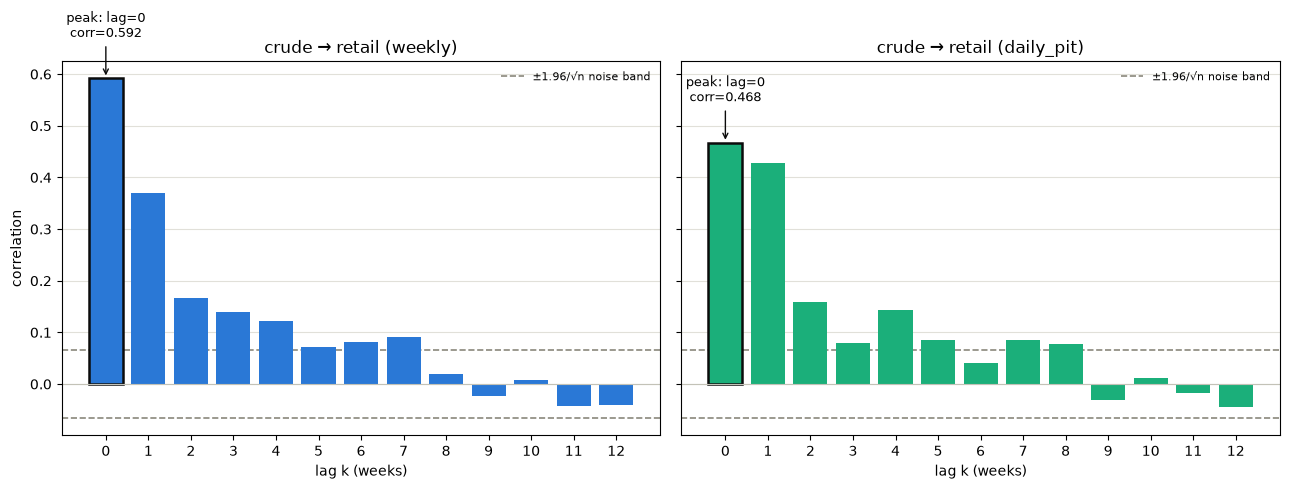

In [2]:
cc_crude_retail_weekly = cross_correlation(retail, weekly_crude, max_lag=MAX_LAG, mode="weekly")
cc_crude_retail_daily_pit = cross_correlation(retail, daily_crude, max_lag=MAX_LAG, mode="daily_pit")

fig, (ax_weekly, ax_daily_pit) = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
plot_cross_correlation(ax_weekly, cc_crude_retail_weekly, COLOR_CRUDE_RETAIL_WEEKLY, "crude \u2192 retail (weekly)")
plot_cross_correlation(ax_daily_pit, cc_crude_retail_daily_pit, COLOR_CRUDE_RETAIL_DAILY_PIT, "crude \u2192 retail (daily_pit)")
ax_weekly.set_ylabel("correlation")
plt.tight_layout()
plt.show()

In [3]:
print("weekly:")
print(cc_crude_retail_weekly.to_string(index=False))
print()
print("daily_pit:")
print(cc_crude_retail_daily_pit.to_string(index=False))

weekly:
 lag  correlation  n_obs
   0     0.591955    864
   1     0.369347    863
   2     0.167108    862
   3     0.140093    861
   4     0.121797    860
   5     0.071414    859
   6     0.081881    858
   7     0.091964    857
   8     0.018915    856
   9    -0.023368    855
  10     0.008313    854
  11    -0.042579    853
  12    -0.039816    852

daily_pit:
 lag  correlation  n_obs
   0     0.467526    864
   1     0.428137    863
   2     0.158718    862
   3     0.079611    861
   4     0.144123    860
   5     0.084888    859
   6     0.040551    858
   7     0.086089    857
   8     0.077649    856
   9    -0.030079    855
  10     0.011778    854
  11    -0.018165    853
  12    -0.044831    852


## 2. Cross-correlation: crude -> wholesale

Here we look at how quickly changes in crude prices are reflected in wholesale prices.
Because the weekly crude and wholesale observations are both dated to Friday, we use daily crude (`DCOILWTICO`) and select the last crude observation strictly before each weekly wholesale date. This keeps the alignment consistent with the point-in-time approach used elsewhere in the project.
We keep wholesale at the weekly frequency. Later, we will also examine the next link in the chain, wholesale → retail, using the same weekly wholesale series.

**What this shows:** how quickly wholesale prices respond to crude price changes, using the same
alignment logic and cross-correlation measure as the other links.

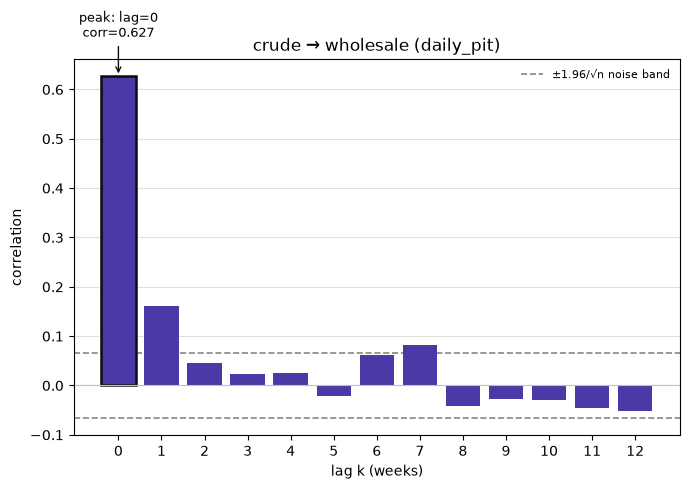

In [4]:
cc_crude_wholesale = cross_correlation(weekly_wholesale, daily_crude, max_lag=MAX_LAG, mode="daily_pit")

fig, ax = plt.subplots(figsize=(7, 5))
plot_cross_correlation(ax, cc_crude_wholesale, COLOR_CRUDE_WHOLESALE, "crude \u2192 wholesale (daily_pit)")
ax.set_ylabel("correlation")
plt.tight_layout()
plt.show()

In [5]:
cc_crude_wholesale

,lag,correlation,n_obs
0,0,0.626821,864
1,1,0.160982,863
2,2,0.045268,862
3,3,0.023275,861
4,4,0.024458,860
5,5,-0.021863,859
6,6,0.061161,858
7,7,0.083035,857
8,8,-0.041011,856
9,9,-0.026771,855


## 3. Cross-correlation: wholesale -> retail
Weekly wholesale is the upstream series and retail is the downstream survey series. They follow the same Friday-to-Monday timing relationship as the primary crude -> retail pair, so the weekly alignment can be used directly.

Comparing it with the crude -> wholesale profile helps show whether the slower response observed at the retail level is already present upstream or emerges between wholesale and retail.

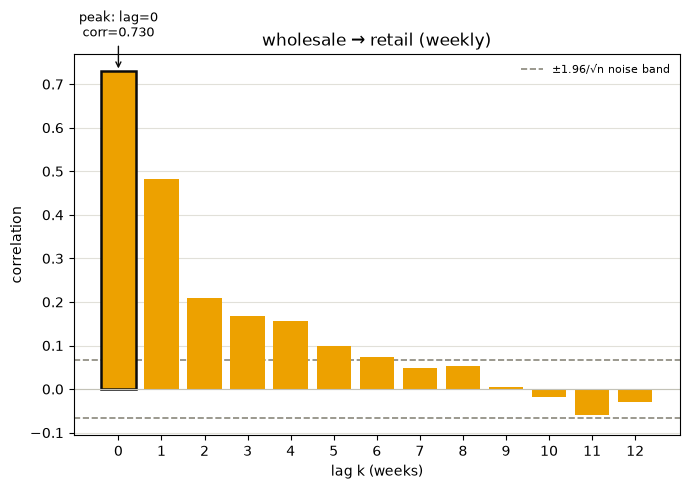

In [6]:
cc_wholesale_retail = cross_correlation(retail, weekly_wholesale, max_lag=MAX_LAG, mode="weekly")

fig, ax = plt.subplots(figsize=(7, 5))
plot_cross_correlation(ax, cc_wholesale_retail, COLOR_WHOLESALE_RETAIL, "wholesale \u2192 retail (weekly)")
ax.set_ylabel("correlation")
plt.tight_layout()
plt.show()

In [7]:
cc_wholesale_retail

,lag,correlation,n_obs
0,0,0.729599,864
1,1,0.482611,863
2,2,0.208491,862
3,3,0.167396,861
4,4,0.157346,860
5,5,0.099965,859
6,6,0.073732,858
7,7,0.047830,857
8,8,0.053003,856
9,9,0.004290,855


### Peak correlation by link
The peak lag and correlation for each profile are summarized here to make the three supply-chain links directly comparable, alongside the two crude -> retail alignments.

In [8]:
def peak_row(name: str, result: pd.DataFrame) -> dict:
    idx = result["correlation"].idxmax()
    return {"pair": name, "peak_lag": result.loc[idx, "lag"], "peak_corr": result.loc[idx, "correlation"], "n_obs_at_peak": result.loc[idx, "n_obs"]}


peaks = pd.DataFrame(
    [
        peak_row("crude \u2192 retail (weekly)", cc_crude_retail_weekly),
        peak_row("crude \u2192 retail (daily_pit)", cc_crude_retail_daily_pit),
        peak_row("crude \u2192 wholesale (daily_pit)", cc_crude_wholesale),
        peak_row("wholesale \u2192 retail (weekly)", cc_wholesale_retail),
    ]
)
peaks

,pair,peak_lag,peak_corr,n_obs_at_peak
0,crude → retail (weekly),0,0.591955,864
1,crude → retail (daily_pit),0,0.467526,864
2,crude → wholesale (daily_pit),0,0.626821,864
3,wholesale → retail (weekly),0,0.729599,864


## 4. Descriptive up/down response: crude -> retail
`up_down_response` shows the average change in retail prices at `horizons h = 0..8` following a crude-price increase or decrease, with ±1 SE error bars.

This is a descriptive view rather than the formal asymmetry test used in `05`. The weeks are grouped only by the direction of the crude-price change, not by the size of the move. If increases and decreases differ systematically in magnitude, that alone could produce different average retail responses even when the underlying pass-through is symmetric.

**What this shows:** the general timing and shape of the retail response to crude increases versus decreases, and the balance between the two groups. The group counts are reported below the chart because an uneven number of up and down weeks affects how much weight to place on the comparison.

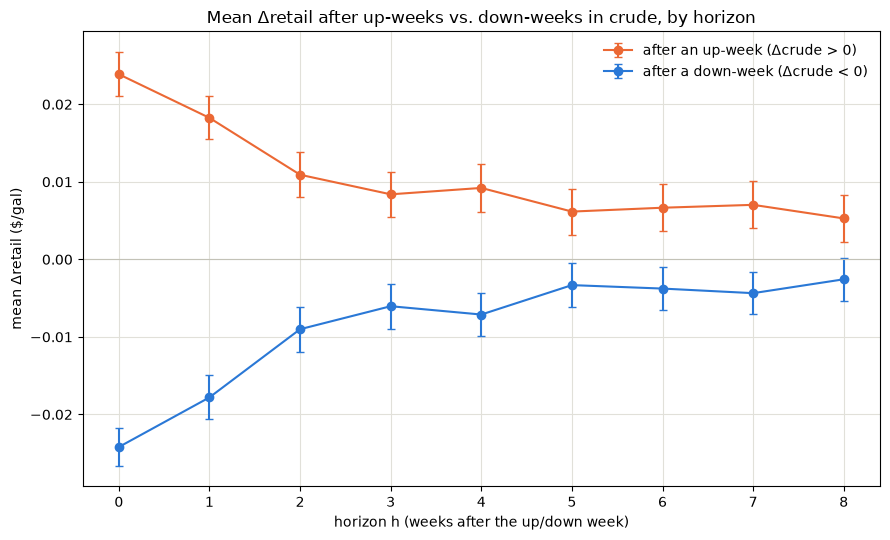

In [9]:
ud = up_down_response(retail, weekly_crude, horizon=8, mode="weekly")

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.errorbar(ud["horizon"], ud["mean_after_up"], yerr=ud["se_up"], marker="o", color=COLOR_UP, label="after an up-week (\u0394crude > 0)", capsize=3)
ax.errorbar(ud["horizon"], ud["mean_after_down"], yerr=ud["se_down"], marker="o", color=COLOR_DOWN, label="after a down-week (\u0394crude < 0)", capsize=3)

ax.set_title("Mean Δretail after up-weeks vs. down-weeks in crude, by horizon", loc="center")
ax.set_xlabel("horizon h (weeks after the up/down week)")
ax.set_ylabel("mean \u0394retail ($/gal)")
ax.set_xticks(ud["horizon"])
ax.axhline(0, color="#c3c2b7", linewidth=0.8)
ax.grid(True, color="#e1e0d9")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [10]:
ud

,horizon,mean_after_up,mean_after_down,n_up,n_down,se_up,se_down
0,0,0.023872,-0.024202,462,401,0.002868,0.002426
1,1,0.018247,-0.017802,462,400,0.002770,0.002829
2,2,0.010911,-0.009010,461,400,0.002880,0.002901
3,3,0.008387,-0.006045,460,400,0.002898,0.002929
4,4,0.009211,-0.007118,459,400,0.003045,0.002719
5,5,0.006161,-0.003323,459,399,0.002962,0.002885
6,6,0.006658,-0.003769,459,398,0.003015,0.002792
7,7,0.007031,-0.004360,459,397,0.003044,0.002752
8,8,0.005279,-0.002573,459,396,0.003077,0.002735


In [11]:
n_up0, n_down0 = ud.loc[0, "n_up"], ud.loc[0, "n_down"]
total = n_up0 + n_down0
print(f"up/down balance at horizon=0: n_up={n_up0} ({n_up0/total:.1%}), n_down={n_down0} ({n_down0/total:.1%}), classified={total} of {len(retail)-1} possible weeks")

up/down balance at horizon=0: n_up=462 (53.5%), n_down=401 (46.5%), classified=863 of 864 possible weeks


## 5. Choosing the lag lengths (K)

For each supply-chain link, `K` is chosen from the cross-correlation profiles above. The goal is to include the part of the lag structure where the correlation shows a sustained relationship with the downstream price, while avoiding isolated values that are consistent with sampling noise.

The specification allows up to 6 lags for the main models. A longer lag window is used later as a sensitivity check where appropriate.

**Noise reference used throughout:** an approximate 95% reference band of ±1.96/√n ≈ ±0.067 (n≈864). This provides a useful benchmark for judging whether a correlation is large enough to stand out from sampling variation under a simple no-correlation approximation. It is not treated as a formal significance test: the assumption behind the reference band is that the differenced series are approximately white noise, whereas some serial dependence remains in the data. The band is therefore used to help interpret the shape of the cross-correlation profiles rather than to determine `K` mechanically.

With 13 lags examined for each pair, some individual correlations can cross the reference band by chance even when there is no underlying relationship. For that reason, an isolated crossing without a supporting pattern in neighboring lags is treated as weak evidence rather than as a reason to extend `K`.

### Crude -> wholesale: K_cw = 1

The correlation drops sharply from 0.627 at lag 0 to 0.161 at lag 1 and 0.045 at lag 2, which is already within the reference noise band. From lag 2 onward, the correlations fluctuate around zero without a sustained decay pattern. Lag 7 reaches 0.083, but this is an isolated bump surrounded by values inside the band, so it is not treated as evidence of a meaningful week 7 effect.

`K_cw = 1` therefore captures the main response of wholesale prices to crude. The rapid decay is consistent with the two markets being closely connected through continuous trading and arbitrage.

### Wholesale -> retail: K_wr = 6

The decay is much slower: correlation falls from 0.730 at lag 0 to 0.483, 0.208, 0.167, 0.157, 0.100, 0.074, and finally 0.048 at lags 1–7. Lag 6 is near the edge of the reference band, while lag 7 is clearly inside it.

Unlike the crude -> wholesale relationship, the decline is gradual and extends across several weeks. This is consistent with a slower retail adjustment process, although the cross-correlation alone does not identify the mechanism behind that delay.

`K_wr = 6` is therefore used for the wholesale -> retail link.

### Crude -> retail (weekly, primary spec): K_cr = 4

The weekly crude → retail correlation declines steadily through lag 4: 0.592 → 0.369 → 0.167 → 0.140 → 0.122. It then falls to 0.071 at lag 5, close to the reference noise band, before showing a small secondary bump at lags 6–7 (0.082 and 0.092).

The lag 6–7 bump is not treated as a separate response because it is isolated and not supported by the surrounding lags. The main correlation pattern has already decayed by this point, so `K_cr = 4` is chosen to capture the primary response without adding a weak secondary feature.

The `daily_pit` alignment provides a useful robustness check on this choice. Under that alignment, lag 0 and lag 1 are much closer (0.468 vs. 0.428) than in the weekly series (0.592 vs. 0.369). This suggests that weekly averaging may shift some of the response that occurs around the survey date into the lag-0 coefficient. It does not, however, provide a reason to extend `K`: the relevant response is still concentrated in the first few weeks.

`K = 6` is used later as a sensitivity check to verify that the asymmetry result does not depend on excluding the lag 6–7 bump.

### Consistency across the supply-chain links

The two individual links imply a total lag structure of roughly `K_cw + K_wr = 1 + 6 = 7` weeks. This is broadly consistent with the direct crude -> retail profile, whose correlation has largely disappeared by lags 6–8.

This is not used as a constraint when choosing `K_cr`. It is a cross-check that the lag structures estimated for the two links are broadly consistent with the direct crude -> retail relationship.